<a href="https://colab.research.google.com/github/HelloSamved/Hands_on_machine_learning/blob/main/Chapter4_Training_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#The Normal Equation:
Basically using this equation we can find the values of w and b which minimizes the cost function.
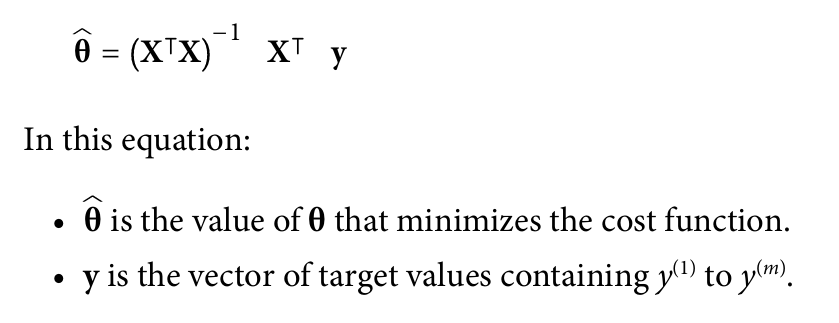

###Let's test this equation by generating some linear looking data

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

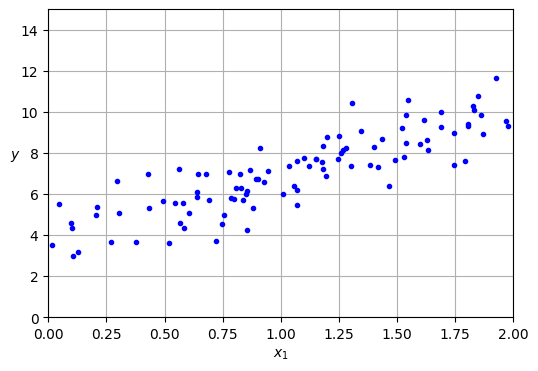

In [4]:
plt.figure(figsize=(6,4))
plt.plot(X,y,"b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

In [5]:
#computing best theta for minimizing cost function using normal equation:
from sklearn.preprocessing import add_dummy_feature
X_b = add_dummy_feature(X)  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[3.7461481 ],
       [3.16513467]])

In [6]:
X_new= np.array([[0],[2]])
X_new_b= np.c_[np.ones((2, 1)), X_new] # add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
y_predict

array([[ 3.7461481 ],
       [10.07641743]])

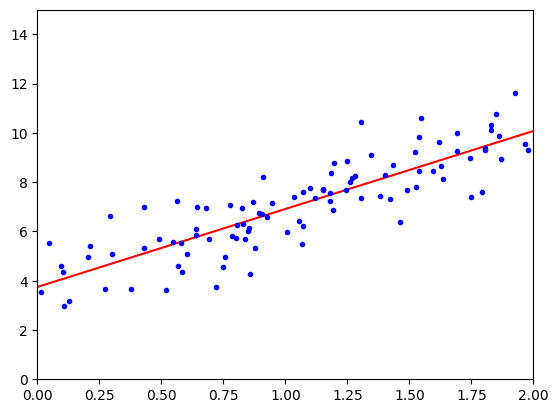

In [7]:
#let's plot this result:
plt.plot(X_new, y_predict, "-r")
plt.plot(X, y, "b.")
plt.axis([0,2,0,15])
plt.show()

In [8]:
#Performing same linear regression but now using scikit-learn:
from sklearn.linear_model import LinearRegression
lin_reg= LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.7461481]), array([[3.16513467]]))

In [9]:
lin_reg.predict(X_new)

array([[ 3.7461481 ],
       [10.07641743]])

###Computational Complexity
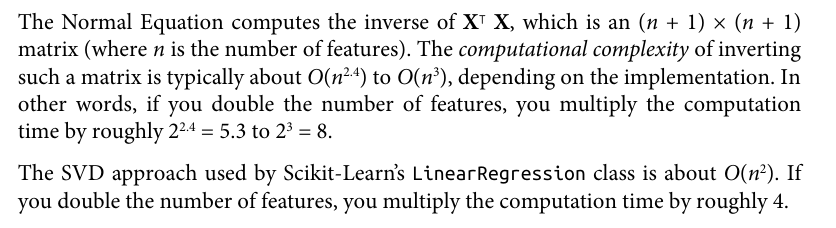

###Gradient Descent
It is a optimization algorithm which is capble of finding optimal solutions to a wide range of problems.
The general idea of this optimization algorithm is to tweak parameters iteratively in order to minimized the cost function.

####For better understanding:
Assume if u need to get down from a mountain u will start walking in the direction of steapest slope.
This is what gradient descent does, it measures the local gradient of error function.
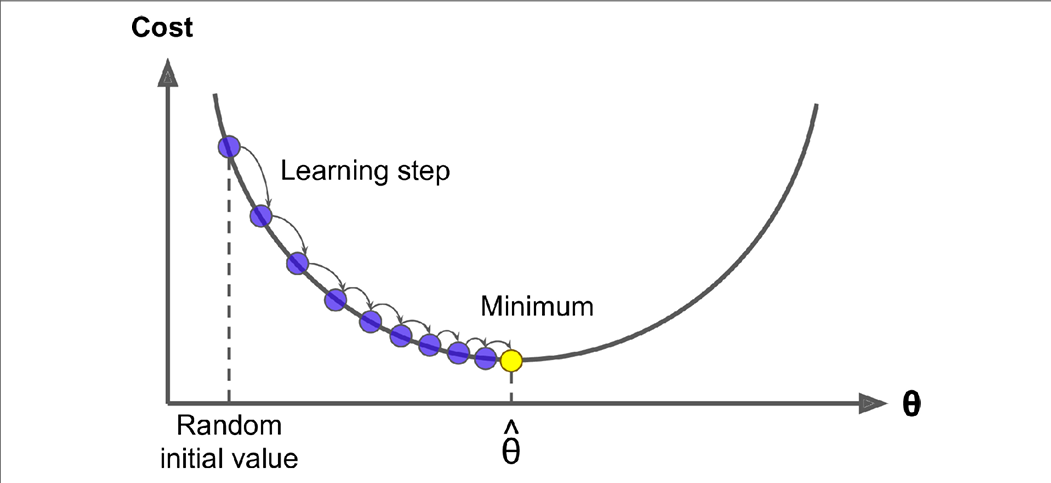

In the above image u might think what is learning step (also known as learning rate) here.
So think of learning rate as size of steps, if the learning rate is too small then our algorithm have to go through many iterations, and if the learning rate is too high, u might got powers like super man (just for fun) and u direcly jump across valley and will not react to the bottom of the valley.

###Batch Gradient Descent


In [10]:
#Quick Implementation:
learning_rate= 0.1
n_epochs= 1000
m= len(X_b)
rng = np.random.default_rng(seed=42)
theta= rng.standard_normal((2,1))
for epochs in range(n_epochs):
  gradients= 2/m * X_b.T.dot(X_b.dot(theta)-y)
  theta= theta-learning_rate*gradients
theta

array([[3.7461481 ],
       [3.16513467]])

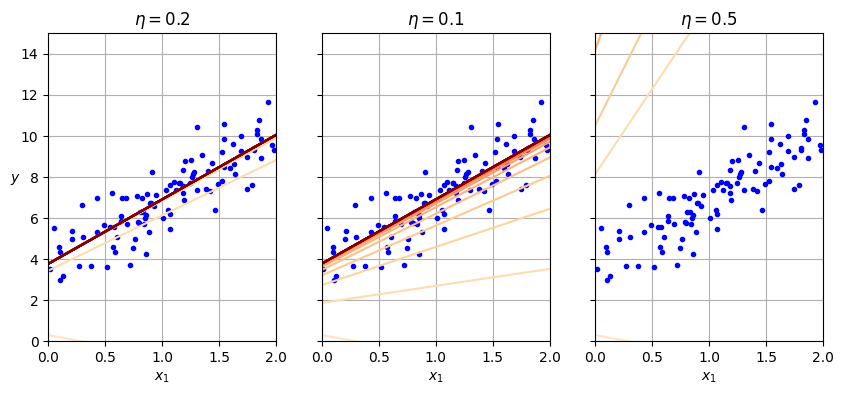

In [11]:
#Ok so now let's plot our gradient descent curve:
import matplotlib as mpl
def plot_gradient_descent(theta, learning_rate):
  m=len(X_b)
  plt.plot(X, y, "b.")
  n_epochs=1000
  n_shown= 20
  theta_path=[]
  for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - learning_rate * gradients
        theta_path.append(theta)
  plt.xlabel("$x_1$")
  plt.axis([0, 2, 0, 15])
  plt.grid()
  plt.title(fr"$\eta = {learning_rate}$")
  return theta_path
rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, learning_rate=0.2)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, learning_rate=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, learning_rate=0.5)
plt.show()


###Stochastic Gradient Descent

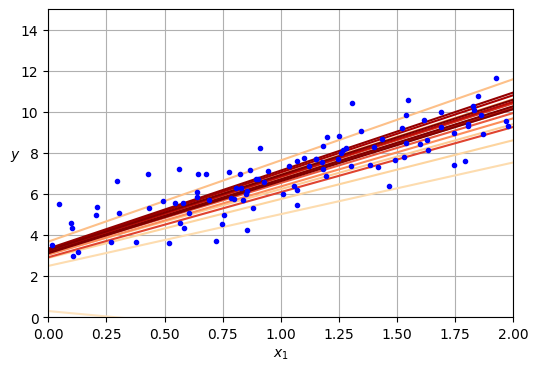

In [12]:
theta_path_sgd = []
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

n_shown = 20  # extra code – just needed to generate the figure below
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting

for epoch in range(n_epochs):
    for iteration in range(m):

        # extra code – these 4 lines are used to generate the figure
        if epoch == 0 and iteration < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(iteration / n_shown + 0.15))
            plt.plot(X_new, y_predict, color=color)

        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)  # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)  # learning rate
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)  # extra code – to generate the figure

# extra code – this section beautifies Figure 4–10
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()

plt.show()

In [13]:
theta

array([[3.81966044],
       [3.13011311]])

In [14]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel())  # y.ravel() because fit() expects 1D targets
sgd_reg.intercept_, sgd_reg.coef_

(array([3.74414649]), array([3.1639492]))

###Mini Batch Gradient Descent

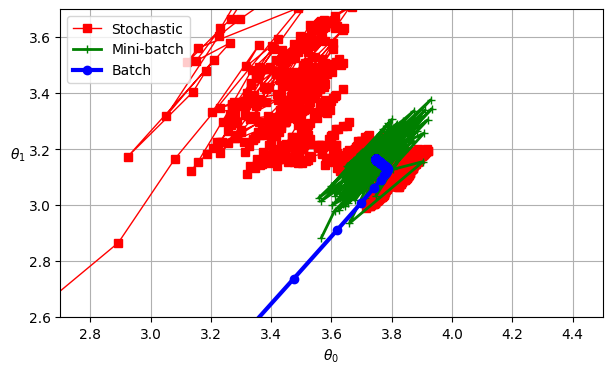

In [15]:
from math import ceil

n_epochs = 50
minibatch_size = 20
n_batches_per_epoch = ceil(m / minibatch_size)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

t0, t1 = 200, 1000  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

theta_path_mgd = []
for epoch in range(n_epochs):
    shuffled_indices = rng.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for iteration in range(0, n_batches_per_epoch):
        idx = iteration * minibatch_size
        xi = X_b_shuffled[idx : idx + minibatch_size]
        yi = y_shuffled[idx : idx + minibatch_size]
        gradients = 2 / minibatch_size * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * n_batches_per_epoch + iteration)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)

theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

plt.figure(figsize=(7, 4))
plt.plot(theta_path_sgd[:, 0], theta_path_sgd[:, 1], "r-s", linewidth=1,
         label="Stochastic")
plt.plot(theta_path_mgd[:, 0], theta_path_mgd[:, 1], "g-+", linewidth=2,
         label="Mini-batch")
plt.plot(theta_path_bgd[:, 0], theta_path_bgd[:, 1], "b-o", linewidth=3,
         label="Batch")
plt.legend(loc="upper left")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$   ", rotation=0)
plt.axis([2.7, 4.5, 2.6, 3.7])
plt.grid()

plt.show()

#Polynomial Regression
What if our data is more complex then a straight line
Well we can use a linear model to fit nonlinear data.
In simple way we do this by adding power of each feature as new features, then train a linear model on this extended set of features.

This whole process is called "Polynomial Regression"

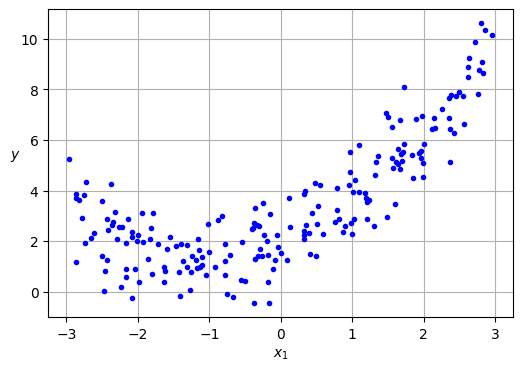

In [16]:
#Example:
rng= np.random.default_rng(seed=42)
m=200
X= 6* rng.random((m,1))-3
y= 0.5*X**2+X+2+rng.standard_normal((m,1))

plt.figure(figsize=(6,4))
plt.plot(X,y,"b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.grid()
plt.show()

In [17]:
from sklearn.preprocessing import PolynomialFeatures
poly_features= PolynomialFeatures()
X_poly= poly_features.fit_transform(X)
X[0], X_poly.shape, X_poly[0]
#From here we get to know that X_poly has a shape of (200,3)

(array([1.64373629]), (200, 3), array([1.        , 1.64373629, 2.701869  ]))

In [18]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([2.00540719]), array([[0.        , 1.11022126, 0.50526985]]))

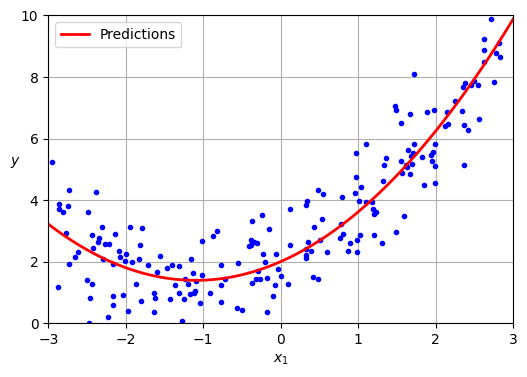

In [19]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()

plt.show()

##Learning Curves

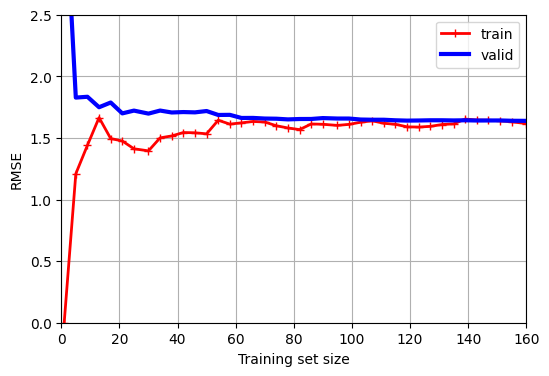

In [20]:
#Learning curve of a plain linear regression model
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores= learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error"
)
train_errors= -train_scores.mean(axis=1)
valid_errors= -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies Figure 4–15
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 160, 0, 2.5])
plt.show()

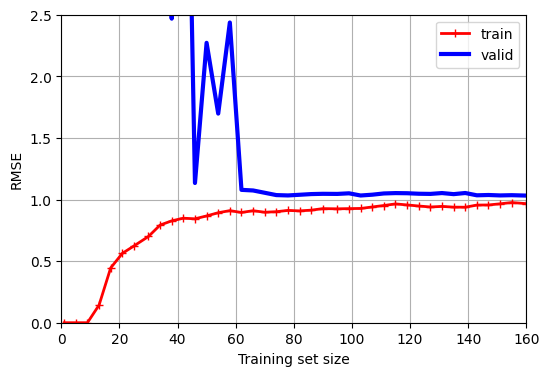

In [21]:
#Learning curve of a 10th degree polynomail
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.axis([0, 160, 0, 2.5])
plt.show()

##Regularized Linear Models
###Ridge Regression
Ridge Regression (also called Tikhonov regularization) is a regularized version of Lin
ear Regression: a regularization term equal to 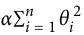
is added to the cost function.
This forces the learning algorithm to not only fit the data but also keep the model
weights as small as possible.


####Ridge Cost Function:
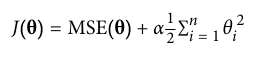

Remeber the bias term is not regularized.

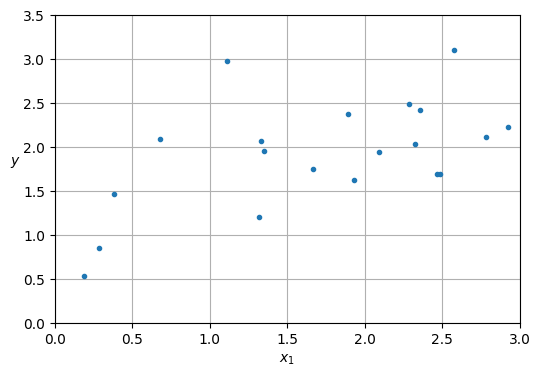

In [22]:
rng = np.random.default_rng(seed=42)
m = 20  # number of instances
X = 3 * rng.random((m, 1))
y = 1 + 0.5 * X + rng.standard_normal((m, 1)) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

plt.figure(figsize=(6, 4))
plt.plot(X, y, ".")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

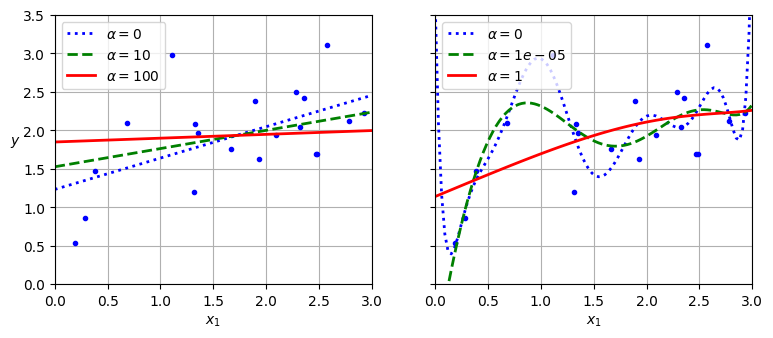

In [23]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

def plot_model(model_class, polynomial, alphas, **model_kwargs):
    plt.plot(X, y, "b.", linewidth=3)
    for alpha, style in zip(alphas, ("b:", "g--", "r-")):
        if alpha > 0:
            model = model_class(alpha, **model_kwargs)
        else:
            model = LinearRegression()
        if polynomial:
            model = make_pipeline(
                PolynomialFeatures(degree=10, include_bias=False),
                StandardScaler(),
                model)
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        plt.plot(X_new, y_new_regul, style, linewidth=2,
                 label=fr"$\alpha = {alpha}$")
    plt.legend(loc="upper left")
    plt.xlabel("$x_1$")
    plt.axis([0, 3, 0, 3.5])
    plt.grid()

plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])

plt.show()

###Lasso Regression
Least Absolute Shrinkage and Selector Operator Regression.
is another regularized version of Linear Regression: just like Ridge
Regression, it adds a regularization term to the cost function, but it uses the ℓ1 norm of the weight vector instead of half the square of the ℓ2 norm

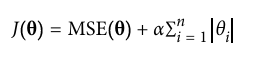

An important characteristic of Lasso Regression is that it tends to eliminate the
weights of the least important features (i.e., set them to zero).

In [24]:
from sklearn.linear_model import Lasso

lasso_reg= Lasso(alpha=0.1)
lasso_reg.fit(X,y)
lasso_reg.predict([[1.5]])

array([1.87550211])

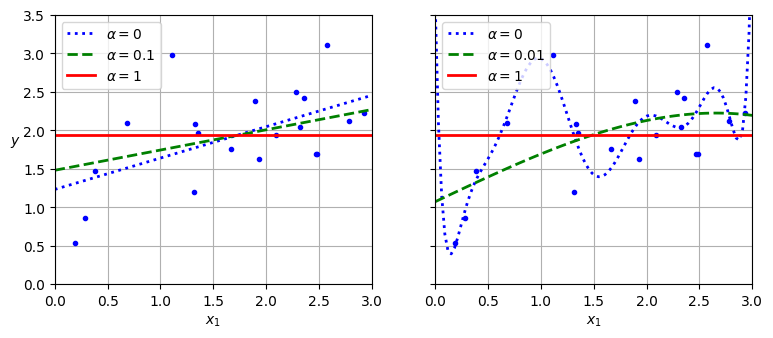

In [25]:
plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 1e-2, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

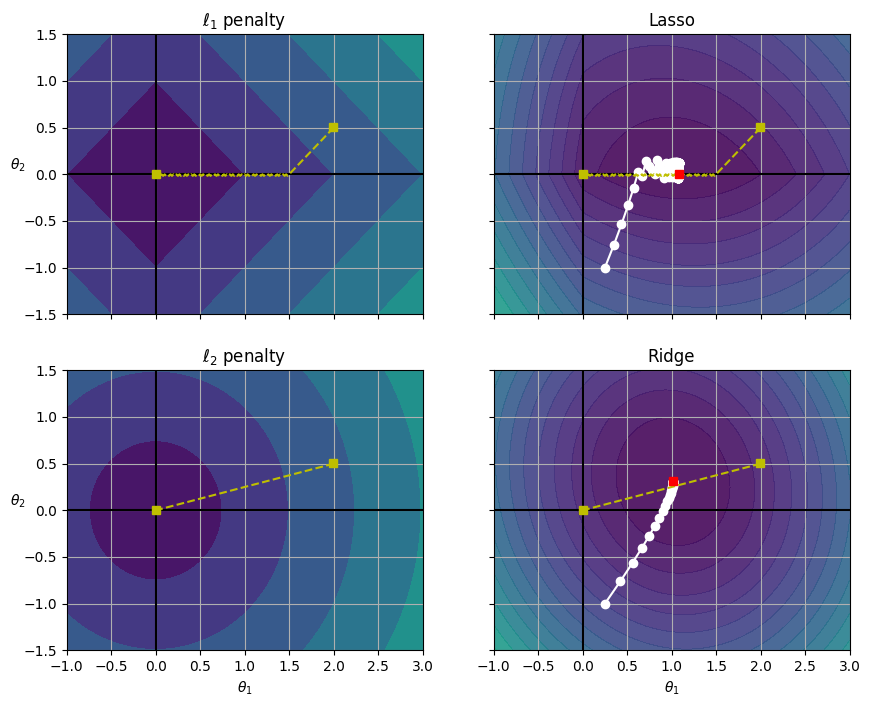

In [26]:
t1a, t1b, t2a, t2b = -1, 3, -1.5, 1.5

t1s = np.linspace(t1a, t1b, 500)
t2s = np.linspace(t2a, t2b, 500)
t1, t2 = np.meshgrid(t1s, t2s)
T = np.c_[t1.ravel(), t2.ravel()]
Xr = np.array([[1, 1], [1, -1], [1, 0.5]])
yr = 2 * Xr[:, :1] + 0.5 * Xr[:, 1:]

J = (1 / len(Xr) * ((T @ Xr.T - yr.T) ** 2).sum(axis=1)).reshape(t1.shape)

N1 = np.linalg.norm(T, ord=1, axis=1).reshape(t1.shape)
N2 = np.linalg.norm(T, ord=2, axis=1).reshape(t1.shape)

t_min_idx = np.unravel_index(J.argmin(), J.shape)
t1_min, t2_min = t1[t_min_idx], t2[t_min_idx]

t_init = np.array([[0.25], [-1]])

def bgd_path(theta, X, y, l1, l2, core=1, eta=0.05, n_iterations=200):
    path = [theta]
    for iteration in range(n_iterations):
        gradients = (core * 2 / len(X) * X.T @ (X @ theta - y)
                     + l1 * np.sign(theta) + l2 * theta)
        theta = theta - eta * gradients
        path.append(theta)
    return np.array(path)

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10.1, 8))

for i, N, l1, l2, title in ((0, N1, 2.0, 0, "Lasso"), (1, N2, 0, 2.0, "Ridge")):
    JR = J + l1 * N1 + l2 * 0.5 * N2 ** 2

    tr_min_idx = np.unravel_index(JR.argmin(), JR.shape)
    t1r_min, t2r_min = t1[tr_min_idx], t2[tr_min_idx]

    levels = np.exp(np.linspace(0, 1, 20)) - 1
    levelsJ = levels * (J.max() - J.min()) + J.min()
    levelsJR = levels * (JR.max() - JR.min()) + JR.min()
    levelsN = np.linspace(0, N.max(), 10)

    path_J = bgd_path(t_init, Xr, yr, l1=0, l2=0)
    path_JR = bgd_path(t_init, Xr, yr, l1, l2)
    path_N = bgd_path(theta=np.array([[2.0], [0.5]]), X=Xr, y=yr,
                      l1=np.sign(l1) / 3, l2=np.sign(l2), core=0)
    ax = axes[i, 0]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, N / 2.0, levels=levelsN)
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.set_title(fr"$\ell_{i + 1}$ penalty")
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$", rotation=0)

    ax = axes[i, 1]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, JR, levels=levelsJR, alpha=0.9)
    ax.plot(path_JR[:, 0], path_JR[:, 1], "w-o")
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.plot(t1r_min, t2r_min, "rs")
    ax.set_title(title)
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")

plt.show()

###Elastic Net
It is a simple mix of both Ridge and Lasso’s regularization terms,
and you can control the mix ratio r

* r = 0, Elastic Net is equivalent to Ridge Regression

* r = 1, Elastic Net is equivalent to Lasso Regression

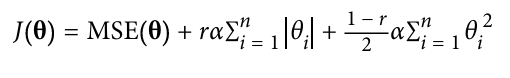


In [27]:
#Quick Implementation:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([1.8645014])

So after studying and knowning all these regularization, everyone should be having a doubt that when should we use plain linear regresssion or when to use regularization.

###When to use plain Linear Regression and when to use Regularization.
####According to the book it is always preferred to have atleast a little bit of regularization.
So according to this u should avoid plain linear regression.
* Use Ridge Regression when most features are useful to prevent overfitting.
* Use Lasso for automatice feature selection when many features are irrelvant
* Use Elastic Net when u have many correlated features, and u need both regularization (to prevent overfitting) and variable selection (to drop unneeded variables).

###Early Stopping
In this method we stop training the model as soon as validation error reaches a minimum

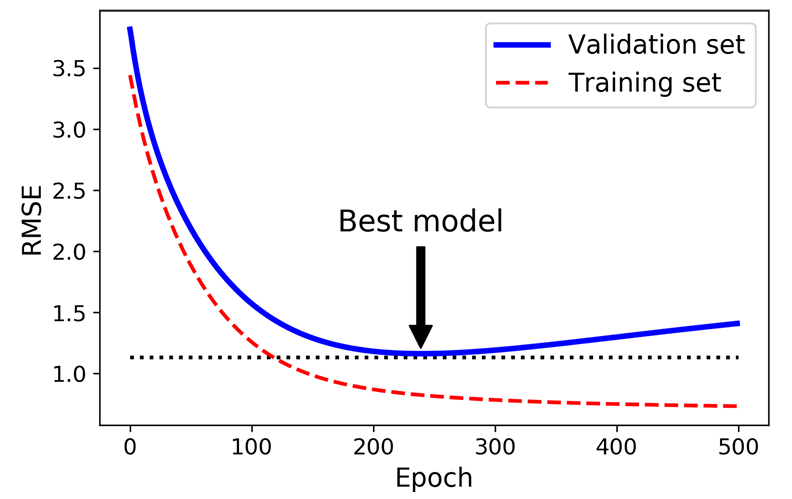

The image shows a complex model (high degree polynomial regression model) being trained using Batch Gradient Descent method.

As the epochs keeps on going, the algorithm learns and the prediction error (RMSE) on the training set goes down, along with its prediction error on the validation set.

Here according to the graphs after training the model for a while our validation error will step decreasing and starts to go up, this indicates the that now the model has started to overfit the training data.

We stop this possibility by Early Stopping method,
we basically did this by stopping the training as soon as the validation error reaches the minimum

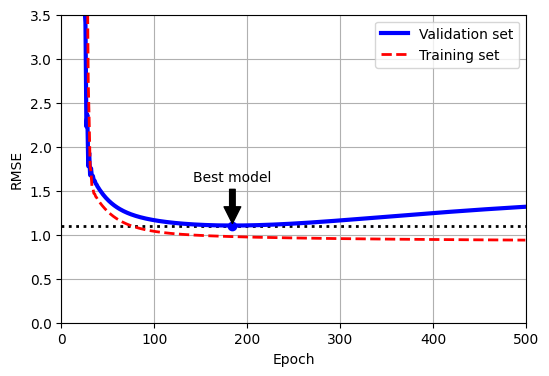

In [28]:
#Basic implementation of early stopping.
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler

# extra code – creates the same quadratic dataset as earlier and splits it
rng = np.random.default_rng(seed=42)
m = 200  # number of instances
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m, 1))
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
train_errors, val_errors = [], []  # extra code – it's for the figure below

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    # extra code – we evaluate the train error and save it for the figure
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = root_mean_squared_error(y_train, y_train_predict)
    val_errors.append(val_error)
    train_errors.append(train_error)

# extra code – this section generates Figure 4–20
best_epoch = np.argmin(val_errors)
plt.figure(figsize=(6, 4))
plt.annotate('Best model',
             xy=(best_epoch, best_valid_rmse),
             xytext=(best_epoch, best_valid_rmse + 0.5),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(best_epoch, best_valid_rmse, "bo")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0, n_epochs, 0, 3.5])
plt.grid()

plt.show()

##Logistic Regression
This is commonly used to estimate the probability that an instance belongs to a particular class

(eg: what is the probability that this email is spam?

ans: The model predicts that the mail is a spam with the probability of more than 50%, than linear regression method defines that this mail should be classified as a spam)

Logistic Regression model also computes a weighted sum of the input features, but instead of giving direct output like in Linear Regression model, it outputs the logistic of the result.

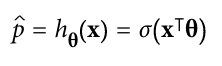

Here σ(·) is a sigmoid function that outputs a number between 0 and 1.

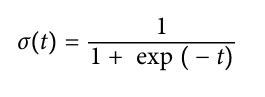

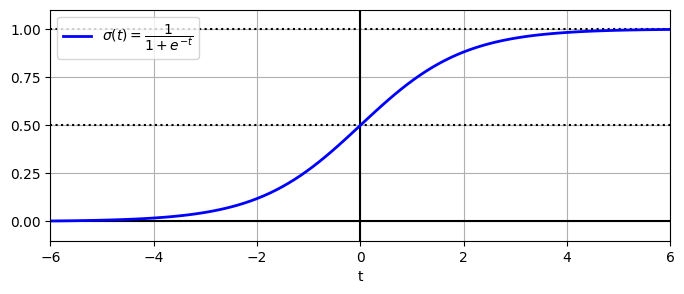

In [30]:
#Estimating Probabilities:
lim = 6
t = np.linspace(-lim, lim, 100)
sig = 1 / (1 + np.exp(-t))

plt.figure(figsize=(8, 3))
plt.plot([-lim, lim], [0, 0], "k-")
plt.plot([-lim, lim], [0.5, 0.5], "k:")
plt.plot([-lim, lim], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(t, sig, "b-", linewidth=2, label=r"$\sigma(t) = \dfrac{1}{1 + e^{-t}}$")
plt.xlabel("t")
plt.legend(loc="upper left")
plt.axis([-lim, lim, -0.1, 1.1])
plt.gca().set_yticks([0, 0.25, 0.5, 0.75, 1])
plt.grid()

plt.show()

###Training and Cost function
Ok so now what we actually mean by training a model?
The objective is the parameter vector θ, so the model estimates high probabilities for positive instances (y=1) and low probabilities for negative instances (y=0)

This idea is captured by cost function shown below:

![image.png](
oUVCoVzp49CzSOZf/1r3+FtbU1tmzZwr7EPNiMyLWNuVqA5eXl5OvrS1ZWVmLr4+mnn6aPP/5YUu/gwYPk6upKffv2pbCwMHrttdfI2dmZtm/fLqlHRPTo0SN67bXXxPvpukaMGEG3bt0SXyMcc9DaQu/Vq1eTq6ur5F5yuZw8PDxIpVKx1dudMGsOgOzt7WnixImUkJAgWfStj7DpraH7IeryySef0FNPPSX+HWxsbMjf359qa2tp+fLl5ODgIMasrKzo+eefp4MHD7K3aVFdXR2hcesuQ87ZaW93796lkJAQeuKJJ2jmzJnk4+NDLi4udPjwYbaq2fAEaGLmSoDGun37NqWmptLFixdb/FCXl5fTyJEj6U9/+hOpVCr697//TSqVit577z3xKYWPPvpIrG/K/fA6itA1DAgIoHPnzlF6ejpbpUXCLueWvjdlZmYm2dvbU3FxMRuyKEVFRXTo0CE6e/Zss6dWzI0nQBOzlARoiPz8fBoyZAj9/e9/Z0NERLRjxw4CQFOnThXLhMOBOvNJcN999x0BoCVLlrAhgwi7QnfE2SCGKisrI2dn5y6zE7e58DHAbqqmpgYvvvgiqqqqEBkZyYaBxkfCwKx5c3FxgbOzM6qqqkw2FtbehPE/YebcWMbuiNPe7t27h5deeglBQUEICwtjw1wTPAF2U5cuXUJxcTEePXqk95GkM2fOoHfv3liwYIGkXNgPLykpSVLeWQgJcNSoUWyoVYWFhcjJyYFCobDIBFheXo6goCAQEWJjY9kwx+AJ0EwsvXU0YsQIDBgwANXV1ZgzZ06zv29GRgYWLlwIlUqF4cOHS2JRUVFAJ02Ad+7cQWZmJmQymUFr1ljC9yz8DCxJQUEBJk6ciGvXruldx8kx2D4x1zbmOhbTHI4fP04DBw4kANS3b18KDAyk6dOnk5eXF40cObLZtlpNCesB23rOS3vRaDSkVqspMDBQnF194403KD4+nq3aIi8vL4IJzgMxtb1795JSqSRra2tSq9VsmNODtwDNhG1RWaIJEybg6tWr2LJlC8LDw+Hk5ISxY8fib3/7GzIyMpptq9WU0AKKj49nQxbp1q1bOHz4MIKCgrBp0ybEx8cjLCzMqLVx2dnZyMnJQXh4uEWdT9PQ0ID//ve/2LZtG27evAk/Pz+2CqeHjAzZwIszWGVlpThpUFhYaFEfFFPz9/dHdnY2srOzO8XmAG3l7e2NwsLCbvP9dge8BWhiSqUSERERqKqqgouLS5vPjbBkSUlJUCqVFjkeZmqxsbHIyclBUlIST35dCE+AZrB69WpMmjQJVVVVXToBKpVKJCUldenvUZCWloaYmBhxBpzrGngX2Iyys7OhVCq7fIuhsLCQf49cp8QTIMdx3RbvAnMc123xBMhxXLfFEyDHcd0WT4Acx3VbPAFyHNdt8QTIcVy3xRMgx3HdFk+AHMd1WzwBchzXbfEEyHFct/X/lQvJJG20IhYAAAAASUVORK5CYII=)

I will also try to justify this function:


As –log(t) grows very large when t approaches 0,
so the cost will be large if the model estimates a probability close to 0 for a positive instance, and it will also be very large if the model estimates a probability close to 1 for a negative instance.

On the other hand, –log(t) is close to 0 when t is close to 1, so
the cost will be close to 0 if the estimated probability is close to 0 for a negative
instance or close to 1 for a positive instance, which is precisely what we want.

###Decesion Boundaries

In [45]:
from sklearn import datasets
iris= datasets.load_iris(as_frame= True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [46]:
iris.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X= iris.data[["petal width (cm)"]].values
y= iris.target_names[iris.target]== 'virginica'

X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=42)

log_reg= LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

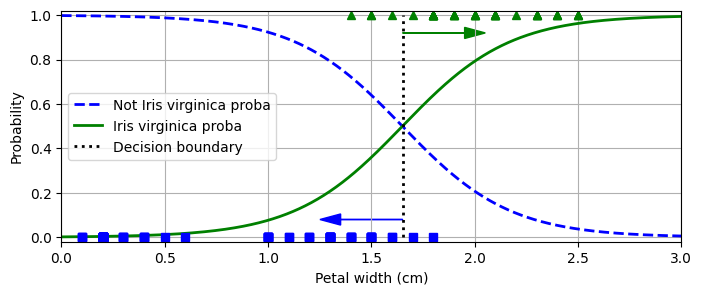

In [49]:
X_new= np.linspace(0,3,1000).reshape(-1,1)
y_proba= log_reg.predict_proba(X_new)
decision_boundary= X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.figure(figsize=(8, 3))  # extra code – not needed, just formatting
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2,
         label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="Decision boundary")

plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="g", ec="g")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()

plt.show()

In [50]:
log_reg.predict([[1.7], [1.5]])

array([ True, False])

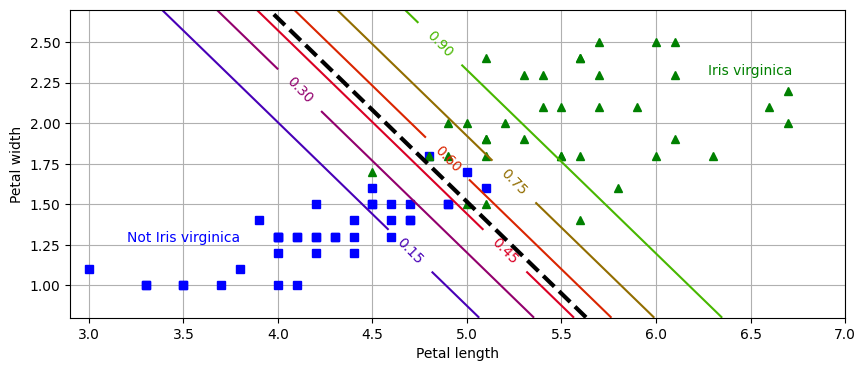

In [51]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(C=2, random_state=42)
log_reg.fit(X_train, y_train)

# for the contour plot
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1),
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]  # one instance per point on the figure
y_proba = log_reg.predict_proba(X_new)
zz = y_proba[:, 1].reshape(x0.shape)

# for the decision boundary
left_right = np.array([2.9, 7])
boundary = -((log_reg.coef_[0, 0] * left_right + log_reg.intercept_[0])
             / log_reg.coef_[0, 1])

plt.figure(figsize=(10, 4))
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], "bs")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], "g^")
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
plt.clabel(contour, inline=1)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.27, "Not Iris virginica", color="b", ha="center")
plt.text(6.5, 2.3, "Iris virginica", color="g", ha="center")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.axis([2.9, 7, 0.8, 2.7])
plt.grid()

plt.show()

###Softmax Regression
This type of logisitic regression model can be generalized to support multiple classes directly

Hence softmax regression is also called Multinomail Logistic Regression.

The idea is simple:

The idea is simple: when given an instance $\mathbf{x}$, the Softmax Regression model first computes a score $s_k(\mathbf{x})$ for each class $k$, then estimates the probability of each class by applying the softmax function (also called the normalized exponential) to the scores. The equation to compute $s_k(\mathbf{x})$ should look familiar, as it is just like the equation for

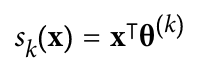

Note that each class has its own dedicated parameter vector $\boldsymbol{\theta}^{(k)}$. All these vectors are typically stored as rows in a \textit{parameter matrix} $\boldsymbol{\Theta}$.

Once you have computed the score of every class for the instance $\mathbf{x}$,
you can estimate the probability $\hat{p}_k$ that the instance belongs to class
$k$ by running the scores through the softmax function.
The function computes the exponential of every score, then normalizes them
(dividing by the sum of all the exponentials). The scores are generally
called logits or log-odds (although they are actually unnormalized log-odds).

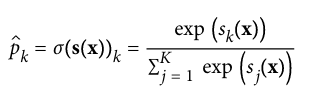

Here in this equation:
* K is the number of classes
* s(x) is a vector containing the scores of each class for the instance x.
* $\sigma(s(\mathbf{x}))_k$ is the estimated probability that the instance $\mathbf{x}$ belongs to class $k$, given the scores of each class for that instance.
